<a href="https://colab.research.google.com/github/Swaraj-sj2000/object_Detection_pipeline_end_to_end/blob/main/multi_modal11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
from kagglehub import dataset_download
from datasets import load_dataset
import matplotlib.pyplot as plt

In [2]:
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

--2026-05-13 05:46:42--  http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.50
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.50|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar [following]
--2026-05-13 05:46:42--  https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar [following]
--2026-05-13 05:46:44--  https://thor.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving thor.robots.ox.ac.uk (thor.ro

In [3]:
!tar -xvf VOCtrainval_11-May-2012.tar

Streaming output truncated to the last 5000 lines.
VOCdevkit/VOC2012/SegmentationClass/2008_001874.png
VOCdevkit/VOC2012/SegmentationClass/2008_001876.png
VOCdevkit/VOC2012/SegmentationClass/2008_001882.png
VOCdevkit/VOC2012/SegmentationClass/2008_001885.png
VOCdevkit/VOC2012/SegmentationClass/2008_001895.png
VOCdevkit/VOC2012/SegmentationClass/2008_001896.png
VOCdevkit/VOC2012/SegmentationClass/2008_001926.png
VOCdevkit/VOC2012/SegmentationClass/2008_001966.png
VOCdevkit/VOC2012/SegmentationClass/2008_001971.png
VOCdevkit/VOC2012/SegmentationClass/2008_001992.png
VOCdevkit/VOC2012/SegmentationClass/2008_001997.png
VOCdevkit/VOC2012/SegmentationClass/2008_002032.png
VOCdevkit/VOC2012/SegmentationClass/2008_002043.png
VOCdevkit/VOC2012/SegmentationClass/2008_002064.png
VOCdevkit/VOC2012/SegmentationClass/2008_002066.png
VOCdevkit/VOC2012/SegmentationClass/2008_002067.png
VOCdevkit/VOC2012/SegmentationClass/2008_002073.png
VOCdevkit/VOC2012/SegmentationClass/2008_002079.png
VOCdevkit/VOC

In [4]:
import os
print(os.listdir("/content/VOCdevkit/VOC2012"))

['Annotations', 'JPEGImages', 'SegmentationObject', 'SegmentationClass', 'ImageSets']


In [5]:
import xml.etree.ElementTree as ET

xml_path = "/content/VOCdevkit/VOC2012/Annotations/2007_000027.xml"

tree = ET.parse(xml_path)
root = tree.getroot()

for child in root:
    print(child.tag)

folder
filename
source
size
segmented
object


In [6]:
l1=set()
base_path="/content/VOCdevkit/VOC2012/Annotations"
xml_files=[os.path.join(base_path,file) for file in os.listdir(base_path)]

for idx,files in enumerate(xml_files):
  #print(idx,files)
  tree = ET.parse(files)
  root=tree.getroot()
  for obj in root.findall('object'):
    label=obj.find('name').text
    l1.add(label)

print(l1)
class_map={label:idx for idx,label in enumerate(sorted(list(l1)))}
print(class_map)

{'horse', 'sofa', 'boat', 'cow', 'motorbike', 'dog', 'diningtable', 'chair', 'train', 'bird', 'cat', 'sheep', 'aeroplane', 'tvmonitor', 'person', 'bicycle', 'car', 'bus', 'pottedplant', 'bottle'}
{'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4, 'bus': 5, 'car': 6, 'cat': 7, 'chair': 8, 'cow': 9, 'diningtable': 10, 'dog': 11, 'horse': 12, 'motorbike': 13, 'person': 14, 'pottedplant': 15, 'sheep': 16, 'sofa': 17, 'train': 18, 'tvmonitor': 19}


In [7]:
IMG_DIR="/content/VOCdevkit/VOC2012/JPEGImages"

def parse_xml(xml_path):
  tree=ET.parse(xml_path)
  root=tree.getroot()

  filename=root.find('filename').text

  image_path=os.path.join(
      IMG_DIR,filename
  )

  size=root.find("size")
  width=float(size.find("width").text)
  height=float(size.find("height").text)

  boxes=[]
  labels=[]

  for obj in root.findall("object"):
    label=obj.find("name").text
    bbox=obj.find("bndbox")

    xmin = float(bbox.find("xmin").text)
    ymin = float(bbox.find("ymin").text)
    xmax = float(bbox.find("xmax").text)
    ymax = float(bbox.find("ymax").text)

    boxes.append([xmin,ymin,xmax,ymax])
    labels.append(class_map[label])

  return {
      "image_path":image_path,
      "width":width,
      "height":height,
      "boxes":boxes,
      "labels":labels
  }


In [8]:
print(parse_xml("/content/VOCdevkit/VOC2012/Annotations/2007_006549.xml"))

{'image_path': '/content/VOCdevkit/VOC2012/JPEGImages/2007_006549.jpg', 'width': 375.0, 'height': 500.0, 'boxes': [[176.0, 20.0, 247.0, 68.0]], 'labels': [3]}


In [9]:
import json

with open("metaddata.json","w") as f:
  metadata = {

    "dataset_name": "VOC2012",

    "num_classes": len(class_map),

    "class_to_id": class_map,

    "id_to_class": {
        str(v): k
        for k, v in class_map.items()
    },

    "image_dir":
    "/content/VOCdevkit/VOC2012/JPEGImages",

    "annotation_dir":
    "/content/VOCdevkit/VOC2012/Annotations",

    "image_format": "jpg",

    "annotation_format": "xml",

    "bbox_format": "xmin_ymin_xmax_ymax"
}
  json.dump(metadata,f,indent=4)


In [10]:
def load_image(image_path, target_size=(224, 224)):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image, channels=3, try_recover_truncated=True)

    image = tf.ensure_shape(image, [None, None, 3])

    image = tf.image.convert_image_dtype(image, tf.float32)

    image = tf.image.resize_with_pad(
        image,
        target_size[0],
        target_size[1]
    )

    image.set_shape([224, 224, 3])

    return image


def normalise_bbox(width,height,bbox):
  xmin,ymin,xmax,ymax=bbox
  xmin=xmin/float(width)
  xmax=xmax/float(width)
  ymin=ymin/float(height)
  ymax=ymax/float(height)

  return [xmin,ymin,xmax,ymax]

In [11]:
xml_path="/content/VOCdevkit/VOC2012/Annotations/2007_000027.xml"
sample=parse_xml(xml_path)
image=load_image(sample["image_path"])

print(image.shape)
print(image.dtype)

print(tf.reduce_min(image))
print(tf.reduce_max(image))

bbox=sample['boxes']
print(bbox)
xmin,ymin,xmax,ymax=bbox[0]
bbox=normalise_bbox(sample['width'],sample['height'],bbox[0])
print(bbox)


(224, 224, 3)
<dtype: 'float32'>
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(1.0, shape=(), dtype=float32)
[[174.0, 101.0, 349.0, 351.0]]
[0.35802469135802467, 0.202, 0.7181069958847737, 0.702]


In [12]:
files=tf.data.Dataset.list_files("/content/VOCdevkit/VOC2012/Annotations/*xml")
print(next(iter(files)))

tf.Tensor(b'/content/VOCdevkit/VOC2012/Annotations/2010_003884.xml', shape=(), dtype=string)


In [13]:
def parse_wrap(x):
    val = parse_xml(x.numpy().decode())

    image_path = val['image_path']
    boxes      = val['boxes']
    labels     = val['labels']
    width      = val['width']
    height     = val['height']

    boxes_n = [normalise_bbox(width, height, box) for box in boxes]

    try:
        image = load_image(image_path)
    except Exception as e:
        image = tf.zeros([224, 224, 3], dtype=tf.float32)

    return (
        image,
        tf.constant(boxes_n, dtype=tf.float32),
        tf.constant(labels,  dtype=tf.int32)
    )

def tf_wrapper(x):
  image,box,label=tf.py_function(
      func=parse_wrap,
      inp=[x],
      Tout=[tf.float32,tf.float32,tf.int32]
  )
  image.set_shape([224,224,3])
  box.set_shape([None,4])
  label.set_shape([None,])
  return image,box,label

In [14]:
path1=next(iter(files))
print(path1)
print(parse_wrap(path1))
image,bbox,label=parse_wrap(path1)
print(image)


tf.Tensor(b'/content/VOCdevkit/VOC2012/Annotations/2010_001455.xml', shape=(), dtype=string)
(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
  

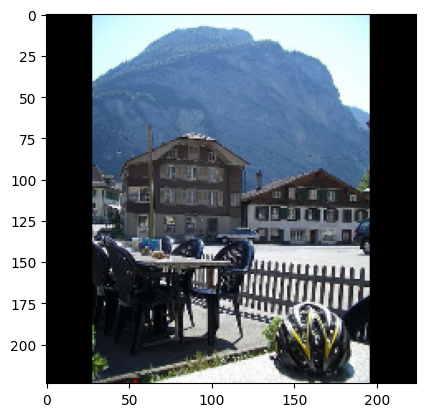

In [15]:
plt.imshow(image.numpy())
plt.show()

In [16]:
dataset=files.map(tf_wrapper,num_parallel_calls=tf.data.AUTOTUNE)
ds=dataset.ragged_batch(32)

b2=next(iter(dataset))
for i in b2:
  print(i)

print(dataset.element_spec)
print(len(ds))
print(len(dataset))
for _, boxes, labels in dataset.take(17000):
    if boxes.shape[0] > 1:
        print(boxes.shape)
        print(labels.shape)
        break

for items in ds.take(1):
 img,box,lbl=items
 print(box.shape)


for idx, items in enumerate(dataset):

    image, boxes, labels = items

    print(image.shape)

    break

tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]], shape=(224, 224, 3), dtype=float32)
tf.Tensor(
[[0.11       0.17783505 0.254      0.31443298]
 [0.372      0.18041237 0.514      0.3015464 ]
 [0.666      0.6005155  0.972      0.87628865]
 [0.664      0.15463917 0.968      0.96391755]], shape=(4, 4), dtype=float32)
tf.Tensor([15 15 19 14], shape=(4,), dtype=int32)
(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dty

In [17]:
def _bytes_format(image):
  return tf.train.Feature(
      bytes_list=tf.train.BytesList(value=[image]))

def _float_format(value):
  return tf.train.Feature(
      float_list=tf.train.FloatList(value=value))

def _int64_format(value):
  return tf.train.Feature(
      int64_list=tf.train.Int64List(value=value)
  )

def _serialize_example(image,box,label):
  boxes=box.numpy()
  xmin=[]
  ymin=[]
  xmax=[]
  ymax=[]

  for b in boxes:
    xmin.append(b[0])
    ymin.append(b[1])
    xmax.append(b[2])
    ymax.append(b[3])




  feature={
      'image':_bytes_format(tf.io.serialize_tensor(image).numpy()),
      'xmin':_float_format(xmin),
      'ymin':_float_format(ymin),
      'xmax':_float_format(xmax),
      'ymax':_float_format(ymax),
      'labels':_int64_format(label.numpy())
  }

  example_proto=tf.train.Example(features=tf.train.Features(feature=feature))
  return example_proto.SerializeToString()

In [18]:
def write_tfrecords(dataset, save_path, prefix, num_shards=10):

    writers = [
        tf.io.TFRecordWriter(
            os.path.join(
                save_path,
                f"{prefix}_{i:03d}.tfrecord"
            )
        )
        for i in range(num_shards)
    ]

    for idx, items in enumerate(dataset):

        if idx % 1000 == 0:
            print(f"{prefix}: {idx}")

        image, boxes, labels = items

        shard_idx = idx % num_shards

        writers[shard_idx].write(
            _serialize_example(
                image,
                boxes,
                labels
            )
        )

    for writer in writers:
        writer.close()

    print(f"{prefix} TFRecords complete.")

In [19]:
dataset_size = len(xml_files)

print(dataset_size)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_files=files.take(train_size)
val_files = files.skip(train_size).take(val_size)
test_files = files.skip(train_size + val_size)

train_ds = train_files.map(
    tf_wrapper,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_files.map(
    tf_wrapper,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_files.map(
    tf_wrapper,
    num_parallel_calls=tf.data.AUTOTUNE
)


17125


In [20]:
SAVE_DIR = "/content/voc2012_tfrecord_v1"

TRAIN_DIR = os.path.join(SAVE_DIR, "train")
VAL_DIR = os.path.join(SAVE_DIR, "val")
TEST_DIR = os.path.join(SAVE_DIR, "test")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)


In [21]:
write_tfrecords(train_ds,TRAIN_DIR,"train",num_shards=10)

write_tfrecords(val_ds,VAL_DIR,"val",num_shards=2)

write_tfrecords(test_ds,TEST_DIR,"test",num_shards=2)

train: 0
train: 1000
train: 2000
train: 3000
train: 4000
train: 5000
train: 6000
train: 7000
train: 8000
train: 9000
train: 10000
train: 11000
train TFRecords complete.
val: 0
val: 1000
val: 2000
val TFRecords complete.
test: 0
test: 1000
test: 2000
test TFRecords complete.


In [22]:
print(os.listdir("/content/"))

['.config', 'VOCtrainval_11-May-2012.tar', 'voc2012_tfrecord_v1', 'metaddata.json', 'VOCdevkit', 'sample_data']


In [23]:
FEATURE_SCHEMA={
    'image':tf.io.FixedLenFeature([],tf.string),
    'xmin':tf.io.VarLenFeature(tf.float32),
    'ymin':tf.io.VarLenFeature(tf.float32),
    'xmax':tf.io.VarLenFeature(tf.float32),
    'ymax':tf.io.VarLenFeature(tf.float32),
    'labels':tf.io.VarLenFeature(tf.int64)
}

In [24]:
def parse_example(example_proto):
    parsed = tf.io.parse_single_example(
        example_proto,
        FEATURE_SCHEMA
    )
    image = tf.io.parse_tensor(
        parsed["image"],
        out_type=tf.float32
    )

    xmin = tf.sparse.to_dense(parsed["xmin"])
    ymin = tf.sparse.to_dense(parsed["ymin"])
    xmax = tf.sparse.to_dense(parsed["xmax"])
    ymax = tf.sparse.to_dense(parsed["ymax"])

    labels = tf.sparse.to_dense(parsed["labels"])

    boxes = tf.stack(
        [xmin, ymin, xmax, ymax],
        axis=1
    )

    image.set_shape([224,224,3])

    return image, boxes, labels


In [25]:
def read_tfrecords(pattern):
  files=tf.data.Dataset.list_files(pattern)
  return files

train_files=read_tfrecords("/content/voc2012_tfrecord_v1/train/*tfrecord")
test_files=read_tfrecords("/content/voc2012_tfrecord_v1/test/*tfrecord")
val_files=read_tfrecords("/content/voc2012_tfrecord_v1/val/*tfrecord")



In [26]:
train_Ds = train_files.interleave(
    lambda x: tf.data.TFRecordDataset(x),
    cycle_length=tf.data.AUTOTUNE,
    num_parallel_calls=tf.data.AUTOTUNE
).map(parse_example,num_parallel_calls=tf.data.AUTOTUNE).shuffle(buffer_size=2000,
                        reshuffle_each_iteration=True)#.padded_batch(32,padded_shapes=([224,224,3],[None,4],[None,]))


test_Ds=test_files.interleave(
    lambda x: tf.data.TFRecordDataset(x),
    cycle_length=tf.data.AUTOTUNE,
    num_parallel_calls=tf.data.AUTOTUNE
).map(parse_example,num_parallel_calls=tf.data.AUTOTUNE)

val_Ds=val_files.interleave(
    lambda x: tf.data.TFRecordDataset(x),
    cycle_length=tf.data.AUTOTUNE,
    num_parallel_calls=tf.data.AUTOTUNE
).map(parse_example,num_parallel_calls=tf.data.AUTOTUNE)


In [27]:
train_size = train_Ds.reduce(
    tf.constant(0, tf.int32),
    lambda state, _: state + 1
)
val_size = val_Ds.reduce(
    tf.constant(0, tf.int32),
    lambda state, _: state + 1
)

test_size = test_Ds.reduce(
    tf.constant(0, tf.int32),
    lambda state, _: state + 1
)

In [28]:
for items in train_Ds.take(1):
  image,box,labels=items
  print(image.shape)
  print(box)
  print(labels)

(224, 224, 3)
tf.Tensor([[0.668 0.352 0.736 0.536]], shape=(1, 4), dtype=float32)
tf.Tensor([14], shape=(1,), dtype=int64)


In [29]:
def get_count(x):
    img, box, lbl = x
    return tf.shape(box)[0]

max_count = train_Ds.reduce(
    tf.constant(0, dtype=tf.int32),
    lambda state, x: tf.maximum(state, get_count(x))
)


In [30]:
print(max_count)

tf.Tensor(56, shape=(), dtype=int32)


In [31]:
counts = train_Ds.map(lambda img, box, lbl: tf.shape(box)[0])

hist = {}

for c in counts:
    c = int(c.numpy())
    hist[c] = hist.get(c, 0) + 1

sorted_hist = sorted(hist.items(), key=lambda x: x[0])
print(sorted_hist)

[(1, 6297), (2, 2400), (3, 1195), (4, 696), (5, 416), (6, 300), (7, 192), (8, 140), (9, 98), (10, 80), (11, 41), (12, 30), (13, 26), (14, 21), (15, 10), (16, 8), (17, 8), (18, 8), (19, 8), (20, 3), (21, 2), (22, 1), (23, 2), (30, 1), (38, 1), (39, 1), (42, 1), (56, 1)]


In [32]:
counts=list(train_Ds.map(lambda img,box,lbl:tf.shape(box)[0]).as_numpy_iterator())
print(counts)

[np.int32(2), np.int32(1), np.int32(5), np.int32(3), np.int32(4), np.int32(1), np.int32(2), np.int32(1), np.int32(2), np.int32(2), np.int32(1), np.int32(1), np.int32(2), np.int32(1), np.int32(1), np.int32(6), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(7), np.int32(2), np.int32(1), np.int32(1), np.int32(3), np.int32(3), np.int32(1), np.int32(2), np.int32(3), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(4), np.int32(2), np.int32(1), np.int32(2), np.int32(4), np.int32(1), np.int32(1), np.int32(1), np.int32(8), np.int32(3), np.int32(2), np.int32(2), np.int32(1), np.int32(1), np.int32(3), np.int32(2), np.int32(1), np.int32(1), np.int32(1), np.int32(2), np.int32(1), np.int32(3), np.int32(8), np.int32(1), np.int32(1), np.int32(1), np.int32(2), np.int32(1), np.int32(2), np.int32(1), np.int32(1), np.int32(2), np.int32(3), np.int32(1), np.int32(1), np.int32(2), np.int32(1), np.int32(30), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(3), np.int32(2

In [33]:
MAX_OBJECTS=np.percentile(counts,98)
print(MAX_OBJECTS)

10.0


In [34]:
import numpy as np
vals = list(hist.keys())
print("95th:", np.percentile(vals, 95))
print("99th:", np.percentile(vals, 99))


95th: 40.949999999999996
99th: 52.220000000000006


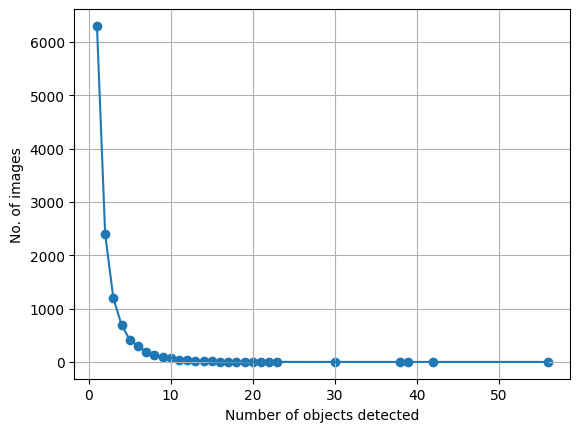

In [35]:
bins=[bin for bin,_ in sorted_hist]
vals=[val for _,val in sorted_hist]
plt.scatter(bins,vals)

plt.plot(bins,vals)
plt.xlabel('Number of objects detected')
plt.ylabel('No. of images')
plt.grid(visible=True)
plt.show()

In [36]:
inputs = tf.keras.Input(shape=(224, 224, 3))
MAX_OBJECTS=25
NUM_CLASSES=20
x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)

outputs = tf.keras.layers.Dense(MAX_OBJECTS * (4 + NUM_CLASSES))(x)
outputs = tf.keras.layers.Reshape((MAX_OBJECTS, 4 + NUM_CLASSES))(outputs)

model = tf.keras.Model(inputs, outputs)

In [37]:
def pad_targets(boxes,labels):
  num=tf.shape(boxes[:MAX_OBJECTS])[0]
  pad_amount=MAX_OBJECTS-num
  padded_boxes=tf.pad(boxes[:MAX_OBJECTS],[[0,pad_amount],[0,0]])
  padded_labels=tf.pad(labels[:MAX_OBJECTS],[[0,pad_amount]],constant_values=-1)

  mask=tf.concat([tf.ones(num),tf.zeros(pad_amount)],axis=0)
  return padded_boxes,padded_labels,mask

In [38]:
train_data = train_Ds.map(lambda img, box, lbl:(img, *pad_targets(box, lbl))).batch(32)
test_data=test_Ds.map(lambda img,box,lbl:(img,*pad_targets(box,lbl))).batch(32)
val_data=val_Ds.map(lambda img,box,lbl:(img,*pad_targets(box,lbl))).batch(32)

In [39]:
for items in train_Ds.take(1):
    print(len(items))
    img, box, lbl = items
    print(img.shape)
    print(box.shape)
    print(lbl.shape)

3
(224, 224, 3)
(1, 4)
(1,)


In [40]:
b2=next(iter(train_Ds))
img,box,lbl=b2
print(img.shape)
print(lbl)
print(lbl.shape)
print(box)
print(box.shape)


(224, 224, 3)
tf.Tensor([14 14], shape=(2,), dtype=int64)
(2,)
tf.Tensor(
[[0.376      0.236      0.872      0.738     ]
 [0.00266667 0.002      0.34666666 0.572     ]], shape=(2, 4), dtype=float32)
(2, 4)


In [41]:
for items in train_data.take(1):
    print(len(items))
    img, box, lbl, mask = items
    print(img.shape)
    print(box.shape)
    print(lbl.shape)
    print(mask.shape)

4
(32, 224, 224, 3)
(32, 25, 4)
(32, 25)
(32, 25)


In [42]:
b2=next(iter(train_data))
img,box,lbl,mask=b2
print(img.shape)
print(lbl)

print(lbl.shape)

print(box)
print(box.shape)
print(mask)
print(mask.shape)


(32, 224, 224, 3)
tf.Tensor(
[[ 4  8 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [16 16 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [ 8  8  8 10 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [ 2 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [ 7 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [ 3  3  3  3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [ 0  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [ 3  3  3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [10  8  8  8  8  7 15 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [ 2 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [14 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [14 14 14 14 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1]
 [ 2 -1 -1 

In [43]:
BATCH_SIZE = 32

train_steps_per_epoch = (
    train_size.numpy() + BATCH_SIZE - 1
) // BATCH_SIZE

val_steps_per_epoch = (
    val_size.numpy() + BATCH_SIZE - 1
) // BATCH_SIZE

print(train_steps_per_epoch)
print(val_steps_per_epoch)

EPOCHS = 10

bbox_loss_fn = tf.keras.losses.Huber(
    reduction='none'
)

cls_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction='none'
)

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=train_steps_per_epoch * EPOCHS,
    alpha=1e-2
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule,
    clipnorm=1.0
)

regularizer = tf.keras.regularizers.l2(1e-4)


class ResidualBlock(tf.keras.layers.Layer):

    def __init__(self, filters):
        super().__init__()

        self.conv1 = tf.keras.layers.Conv2D(
            filters,
            3,
            padding="same",
            use_bias=False,
            kernel_regularizer=regularizer
        )

        self.bn1 = tf.keras.layers.BatchNormalization()

        self.conv2 = tf.keras.layers.Conv2D(
            filters,
            3,
            padding="same",
            use_bias=False,
            kernel_regularizer=regularizer
        )

        self.bn2 = tf.keras.layers.BatchNormalization()

    def call(self, x, training=False):

        shortcut = x

        x = self.conv1(x)
        x = self.bn1(x, training=training)
        x = tf.nn.relu(x)

        x = self.conv2(x)
        x = self.bn2(x, training=training)

        x = x + shortcut

        x = tf.nn.relu(x)

        return x


class Detector(tf.keras.Model):

    def __init__(self, num_classes=20, max_objects=25):
        super().__init__()

        self.num_classes = num_classes
        self.max_objects = max_objects

        self.conv1 = tf.keras.layers.Conv2D(32,3,padding="same",use_bias=False,kernel_regularizer=regularizer)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.pool1 = tf.keras.layers.MaxPooling2D()

        self.res1 = ResidualBlock(32)

        self.conv2 = tf.keras.layers.Conv2D(64,3,padding="same", use_bias=False,kernel_regularizer=regularizer)
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.pool2 = tf.keras.layers.MaxPooling2D()

        self.res2 = ResidualBlock(64)

        self.conv3 = tf.keras.layers.Conv2D(128,3,padding="same",use_bias=False,kernel_regularizer=regularizer)
        self.bn3 = tf.keras.layers.BatchNormalization()
        self.pool3 = tf.keras.layers.MaxPooling2D()

        self.res3 = ResidualBlock(128)

        self.conv4 = tf.keras.layers.Conv2D(256,3,padding="same",use_bias=False,kernel_regularizer=regularizer)
        self.bn4 = tf.keras.layers.BatchNormalization()
        self.pool4 = tf.keras.layers.MaxPooling2D()

        self.conv5 = tf.keras.layers.Conv2D(512,3,strides=2,padding="same",use_bias=False,kernel_regularizer=regularizer)
        self.bn5 = tf.keras.layers.BatchNormalization()
        # self.gap = tf.keras.layers.GlobalAveragePooling2D() # Removed as requested

        self.fc1 = tf.keras.layers.Dense(512,activation="relu",kernel_regularizer=regularizer)

        self.dropout = tf.keras.layers.Dropout(0.2)

        self.output_layer = tf.keras.layers.Dense(max_objects * (4 + 1 + num_classes))

        self.reshape = tf.keras.layers.Reshape((max_objects, 4 + 1 + num_classes))


    def call(self, inputs, training=False):

        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = tf.nn.relu(x)

        x = self.pool1(x)

        x = self.res1(x, training=training)

        x = self.conv2(x)
        x = self.bn2(x, training=training)
        x = tf.nn.relu(x)

        x = self.pool2(x)

        x = self.res2(x, training=training)

        x = self.conv3(x)
        x = self.bn3(x, training=training)
        x = tf.nn.relu(x)

        x = self.pool3(x)

        x = self.res3(x, training=training)

        x = self.conv4(x)
        x = self.bn4(x, training=training)
        x = tf.nn.relu(x)

        x = self.pool4(x)

        x = self.conv5(x)
        x = self.bn5(x, training=training)
        x = tf.nn.relu(x)
        #x = self.gap(x)
        x = tf.keras.layers.Flatten()(x)

        x = self.fc1(x)

        x = self.dropout(x,training=training)

        x = self.output_layer(x)

        outputs = self.reshape(x)

        return outputs

375
81


In [44]:
model=Detector(num_classes=20,max_objects=25)

In [45]:
@tf.function
def train_step(images,true_box,true_labels,mask):

    with tf.GradientTape() as tape:

        preds=model(images,training=True)

        pred_boxes=preds[...,:4]
        pred_obj=preds[...,4]
        pred_logits=preds[...,5:]

        bbox_loss = bbox_loss_fn(true_box, pred_boxes) * mask
        obj_loss=tf.nn.sigmoid_cross_entropy_with_logits(labels=mask,logits=pred_obj)

        safe_labels = tf.where(true_labels == -1, tf.zeros_like(true_labels), true_labels)
        cls_loss = cls_loss_fn(safe_labels,pred_logits) * mask

        total_loss = tf.reduce_sum(3.0 * bbox_loss +1.0 * obj_loss +1.0 * cls_loss) / (tf.reduce_sum(mask)+1e-8)

    grads,_=tf.clip_by_global_norm(tape.gradient(total_loss, model.trainable_variables),10.0)

    optimizer.apply_gradients(zip(grads,model.trainable_variables))

    return total_loss,tf.linalg.global_norm(grads)

In [46]:
@tf.function
def val_step(images, true_box, true_labels, mask):

    preds = model(images, training=False)

    pred_boxes = preds[..., :4]
    pred_obj = preds[..., 4]
    pred_logits = preds[..., 5:]

    bbox_loss = bbox_loss_fn(
        true_box,
        pred_boxes
    ) * mask

    obj_loss = tf.nn.sigmoid_cross_entropy_with_logits(
        labels=mask,
        logits=pred_obj
    )

    safe_labels = tf.where(
        true_labels == -1,
        tf.zeros_like(true_labels),
        true_labels
    )

    cls_loss = cls_loss_fn(
        safe_labels,
        pred_logits
    ) * mask

    total_loss = tf.reduce_sum(3.0 * bbox_loss
                               +1.0 * obj_loss
                               +1.0 * cls_loss) / (tf.reduce_sum(mask) + 1e-8)

    return total_loss

In [47]:
b1=next(iter(train_data))
img,box,lbl,mask=b1
sample_img=img[0]
print(sample_img.shape)


(224, 224, 3)


In [48]:
pred=model.call(tf.expand_dims(sample_img,axis=0))
print(pred)

tf.Tensor(
[[[-3.09063075e-03  2.40916740e-02 -2.62941867e-02 -2.20720284e-02
   -8.80010054e-02 -9.77021605e-02  2.46470645e-02  6.36373311e-02
    3.14294286e-02 -9.83317476e-03  1.23974215e-02 -1.25835659e-02
    7.74011612e-02  2.84485389e-02 -4.11568582e-02 -1.09008886e-02
   -2.81347632e-02 -4.89914604e-02  2.05741823e-03  3.63243148e-02
   -1.52479159e-02 -1.53162843e-02 -7.18015507e-02  1.67818833e-02
    8.82729068e-02]
  [ 2.39915177e-02  1.55767342e-02 -3.39405076e-03 -2.84753144e-02
    3.52379866e-02  6.34405836e-02 -2.86244554e-03  5.15621230e-02
   -7.52949156e-03 -1.72087085e-02 -3.56132314e-02  7.42166042e-02
    5.48425727e-02  6.46550134e-02 -1.66615937e-03  3.42648625e-02
    7.12841097e-03  3.62183154e-02  4.89034317e-03  3.85267623e-02
    3.23968902e-02  7.20451027e-02  3.38091142e-02  8.40810873e-03
   -1.40378587e-02]
  [-5.33270650e-03  6.48505846e-03 -2.76848078e-02  3.88038764e-03
    4.54037637e-02 -5.12777977e-02 -1.12192463e-02  2.99980771e-02
    2.94815

In [ ]:

from tqdm.auto import tqdm


train_loss_history = []
val_loss_history = []

grad_norm_history = []

for epoch in range(EPOCHS):

    train_total_loss = 0.0
    train_steps = 0

    progress_bar = tqdm(train_data,
                        total=train_steps_per_epoch,
                        desc=f"Epoch {epoch+1}/{EPOCHS}",
                        leave=True)

    for images, boxes, labels, mask in progress_bar:

        loss, grad_norm = train_step(images, boxes, labels, mask)

        train_total_loss += loss
        train_steps += 1

        train_loss_history.append(loss.numpy())
        grad_norm_history.append(grad_norm.numpy())

        progress_bar.set_postfix({
            "batch_loss": f"{loss.numpy():.4f}",
            "grad_norm": f"{grad_norm.numpy():.4f}"})

    avg_train_loss = (train_total_loss / train_steps).numpy()

    val_total_loss = 0.0
    val_steps = 0

    val_bar = tqdm( val_data, total=val_steps_per_epoch, desc="Validation",leave=False)

    for images, boxes, labels, mask in val_bar:

        val_loss = val_step(images,boxes,labels,mask)

        val_total_loss += val_loss
        val_steps += 1

        val_bar.set_postfix({"val_batch_loss": f"{val_loss.numpy():.4f}"})

    avg_val_loss = (val_total_loss / val_steps ).numpy()

    val_loss_history.append(avg_val_loss)

    print(
        f"\nEpoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}\n"
        )

Epoch 1/10:   0%|          | 0/375 [00:00<?, ?it/s]

Validation:   0%|          | 0/81 [00:00<?, ?it/s]


Epoch 1/10 | Train Loss: 4.3783 | Val Loss: 4.1365



Epoch 2/10:   0%|          | 0/375 [00:00<?, ?it/s]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,12))

plt.subplot(2,2,1)
plt.plot(train_loss_history)
plt.title("Loss History")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(grad_norm_history)
plt.title("Gradient Norm History")
plt.xlabel("Training Step")
plt.ylabel("Gradient Norm")
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(val_loss_history)
plt.title("Validation loss History")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [ ]:
test_total_loss = 0.0
test_steps = 0

for images, boxes, labels, mask in test_data:

    test_loss = val_step(
        images,
        boxes,
        labels,
        mask
    )

    test_total_loss += test_loss
    test_steps += 1

avg_test_loss = (
    test_total_loss / test_steps
).numpy()

print(f"Final Test Loss: {avg_test_loss:.4f}")